In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
print(real_metrics)
print(aug_metrics)

print(real_metrics["model"].unique())
print(aug_metrics["model"].unique())

       model  accuracy  precision    recall  f1_score     auroc
0  real_only  0.982456        1.0  0.952381   0.97561  0.993386
                 model  accuracy  precision  recall  f1_score  auroc
0  real_plus_synthetic       1.0        1.0     1.0       1.0    1.0
['real_only']
['real_plus_synthetic']


### Load Parquet Files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_metrics = pd.read_parquet("results/real/metrics.parquet")
real_roc = pd.read_parquet("results/real/roc_points.parquet")
real_certainty = pd.read_parquet("results/real/posterior_prediction_summary.parquet")

aug_metrics = pd.read_parquet("results/augmented/metrics.parquet")
aug_roc = pd.read_parquet("results/augmented/roc_points.parquet")
aug_certainty = pd.read_parquet("results/augmented/posterior_prediction_summary.parquet")

metrics_df = pd.concat([real_metrics, aug_metrics], ignore_index=True)
roc_df = pd.concat([real_roc, aug_roc], ignore_index=True)
certainty_df = pd.concat([real_certainty, aug_certainty], ignore_index=True)

In [2]:
metrics_df

,model,accuracy,precision,recall,f1_score,auroc
0,real_only,0.982456,1.0,0.952381,0.97561,0.993386
1,real_plus_synthetic,1.000000,1.0,1.000000,1.00000,1.000000


### Plot Performance Metrics

In [ ]:
certainty_summary = (
    certainty_df
    .groupby("model")[["sd_prob", "interval_width", "entropy"]]
    .mean()
    .reset_index()
)

certainty_cols = ["sd_prob", "interval_width", "entropy"]

certainty_baseline = certainty_summary.loc[
    certainty_summary["model"] == "real_only",
    certainty_cols
].iloc[0]

certainty_vs_real = certainty_summary.copy()
for col in certainty_cols:
    certainty_vs_real[f"{col}_diff_vs_real"] = certainty_vs_real[col] - certainty_baseline[col]

certainty_vs_real

,model,sd_prob,interval_width,entropy,sd_prob_diff_vs_real,interval_width_diff_vs_real,entropy_diff_vs_real
0,real_only,0.029138,0.096026,0.066504,0.00000,0.000000,0.000000
1,real_plus_synthetic,0.020988,0.072852,0.075996,-0.00815,-0.023174,0.009491


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

wide_sd = certainty_df.pivot(
    index="row_id",
    columns="model",
    values="sd_prob"
).dropna()

wide_sd["diff"] = wide_sd["real_plus_synthetic"] - wide_sd["real_only"]
wide_sd.head()

model,real_only,real_plus_synthetic,diff
row_id,,,
1,5.878164e-08,0.000001,0.000001
2,3.387661e-05,0.000169,0.000135
3,3.047055e-02,0.047225,0.016755
4,5.104659e-03,0.004832,-0.000273
5,4.466797e-03,0.016386,0.011920


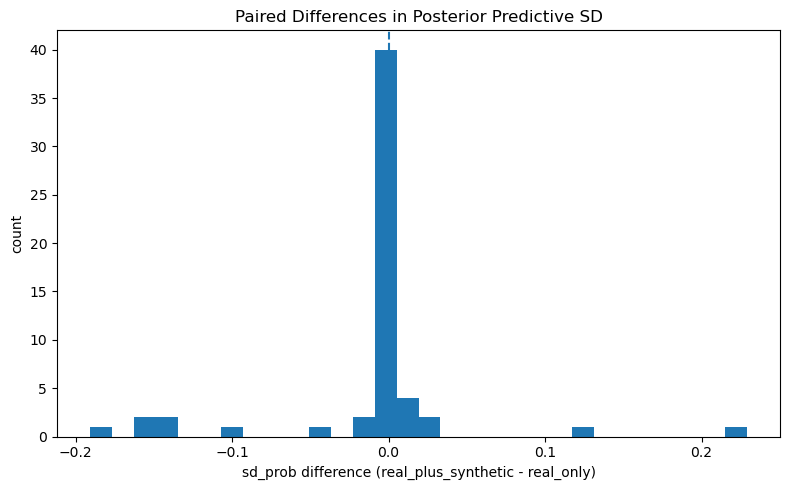

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(wide_sd["diff"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("sd_prob difference (real_plus_synthetic - real_only)")
plt.ylabel("count")
plt.title("Paired Differences in Posterior Predictive SD")
plt.tight_layout()
plt.show()

In [8]:
t_stat, p_val = ttest_rel(
    wide_sd["real_plus_synthetic"],
    wide_sd["real_only"]
)

print("paired t-test")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("mean difference:", wide_sd["diff"].mean())

paired t-test
t-statistic: -1.0304121851395023
p-value: 0.30724648820944295
mean difference: -0.008150084590276132


In [9]:
w_stat, w_p = wilcoxon(
    wide_sd["real_plus_synthetic"],
    wide_sd["real_only"]
)

print("wilcoxon signed-rank test")
print("statistic:", w_stat)
print("p-value:", w_p)

wilcoxon signed-rank test
statistic: 615.0
p-value: 0.09287727800263469


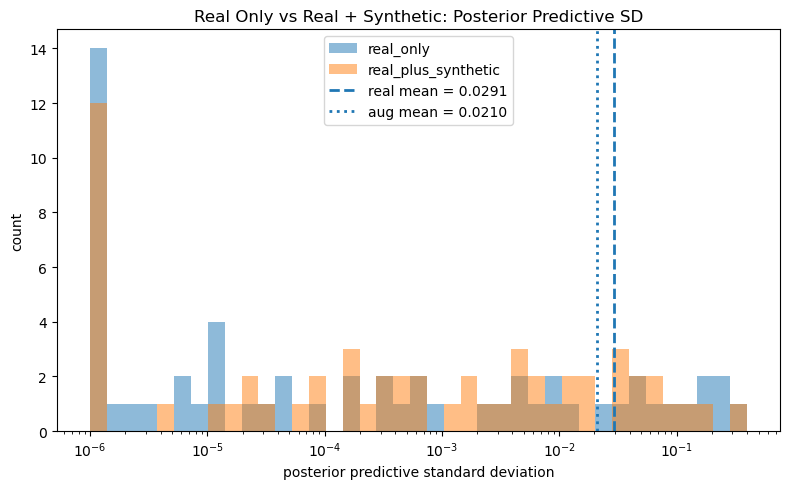

In [25]:
import numpy as np
import matplotlib.pyplot as plt

real_sd = certainty_df.loc[certainty_df["model"] == "real_only", "sd_prob"].dropna()
aug_sd = certainty_df.loc[certainty_df["model"] == "real_plus_synthetic", "sd_prob"].dropna()

bins = np.logspace(np.log10(1e-6), np.log10(0.4), 40)

plt.figure(figsize=(8, 5))

plt.hist(np.clip(real_sd, 1e-6, None), bins=bins, alpha=0.5, label="real_only")
plt.hist(np.clip(aug_sd, 1e-6, None), bins=bins, alpha=0.5, label="real_plus_synthetic")

plt.axvline(real_sd.mean(), linestyle="--", linewidth=2, label=f"real mean = {real_sd.mean():.4f}")
plt.axvline(aug_sd.mean(), linestyle=":", linewidth=2, label=f"aug mean = {aug_sd.mean():.4f}")

plt.xscale("log")
plt.xlabel("posterior predictive standard deviation")
plt.ylabel("count")
plt.title("Real Only vs Real + Synthetic: Posterior Predictive SD")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import ks_2samp

real_sd = certainty_df.loc[certainty_df["model"] == "real_only", "sd_prob"].dropna()
aug_sd = certainty_df.loc[certainty_df["model"] == "real_plus_synthetic", "sd_prob"].dropna()

ks_stat, ks_p = ks_2samp(real_sd, aug_sd)

print("KS statistic:", ks_stat)
print("KS p-value:", ks_p)

KS statistic: 0.17543859649122806
KS p-value: 0.34661391534207175


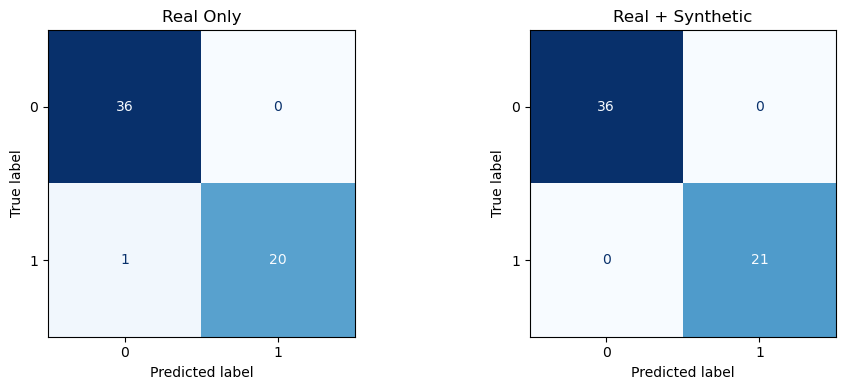

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

real_preds = pd.read_parquet("results/real/predictions.parquet")
aug_preds = pd.read_parquet("results/augmented/predictions.parquet")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_real = confusion_matrix(real_preds["y_true"], real_preds["y_pred"])
cm_aug = confusion_matrix(aug_preds["y_true"], aug_preds["y_pred"])

ConfusionMatrixDisplay(cm_real).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Real Only")

ConfusionMatrixDisplay(cm_aug).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Real + Synthetic")

plt.tight_layout()
plt.show()

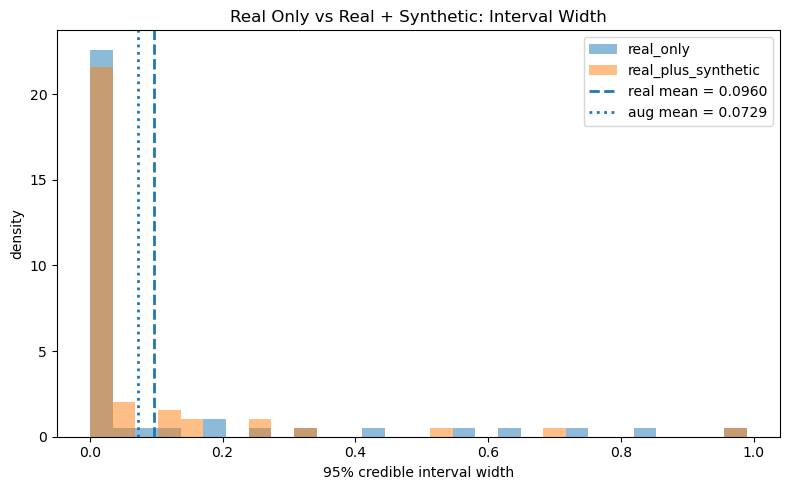

In [23]:
import numpy as np
import matplotlib.pyplot as plt

real_w = certainty_df.loc[certainty_df["model"] == "real_only", "interval_width"].dropna()
aug_w = certainty_df.loc[certainty_df["model"] == "real_plus_synthetic", "interval_width"].dropna()

all_vals = np.concatenate([real_w.values, aug_w.values])
bins = np.linspace(all_vals.min(), all_vals.max(), 30)

plt.figure(figsize=(8, 5))
plt.hist(real_w, bins=bins, alpha=0.5, density=True, label="real_only")
plt.hist(aug_w, bins=bins, alpha=0.5, density=True, label="real_plus_synthetic")
plt.axvline(real_w.mean(), linestyle="--", linewidth=2, label=f"real mean = {real_w.mean():.4f}")
plt.axvline(aug_w.mean(), linestyle=":", linewidth=2, label=f"aug mean = {aug_w.mean():.4f}")
plt.xlabel("95% credible interval width")
plt.ylabel("density")
plt.title("Real Only vs Real + Synthetic: Interval Width")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
certainty_df["boundary_distance"] = (certainty_df["mean_prob"] - 0.5).abs()
boundary_summary = (
    certainty_df
    .groupby("model")[["boundary_distance"]]
    .mean()
    .reset_index()
)

boundary_summary

,model,boundary_distance
0,real_only,0.473929
1,real_plus_synthetic,0.473725


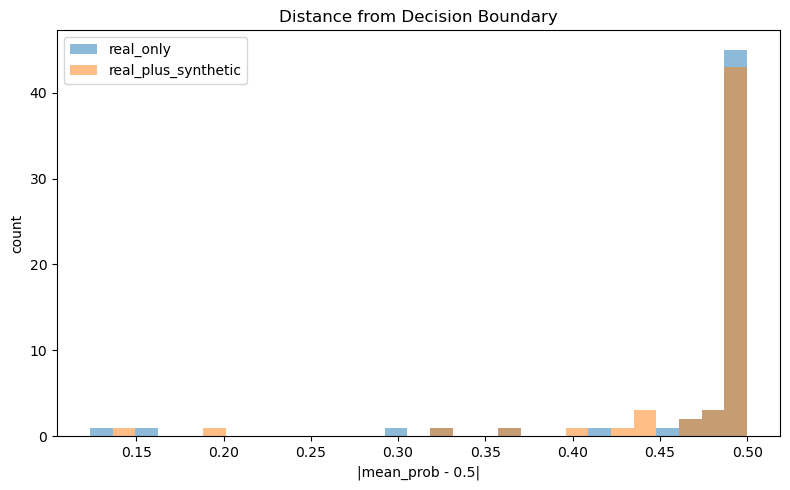

In [ ]:
real_bd = certainty_df.loc[certainty_df["model"] == "real_only", "boundary_distance"].dropna()
aug_bd = certainty_df.loc[certainty_df["model"] == "real_plus_synthetic", "boundary_distance"].dropna()
import numpy as np
import matplotlib.pyplot as plt

all_vals = np.concatenate([real_bd.values, aug_bd.values])
bins = np.linspace(all_vals.min(), all_vals.max(), 30)

plt.figure(figsize=(8, 5))
plt.hist(real_bd, bins=bins, alpha=0.5, label="real_only")
plt.hist(aug_bd, bins=bins, alpha=0.5, label="real_plus_synthetic")
plt.xlabel("|mean_prob - 0.5|")
plt.ylabel("count")
plt.title("Distance from Decision Boundary")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from scipy.stats import ttest_rel, wilcoxon

wide_bd = certainty_df.pivot(
    index="row_id",
    columns="model",
    values="boundary_distance"
).dropna()

wide_bd["diff"] = wide_bd["real_plus_synthetic"] - wide_bd["real_only"]

print("mean difference:", wide_bd["diff"].mean())

t_stat, p_val = ttest_rel(
    wide_bd["real_plus_synthetic"],
    wide_bd["real_only"]
)
print("paired t-test p-value:", p_val)

w_stat, w_p = wilcoxon(
    wide_bd["real_plus_synthetic"],
    wide_bd["real_only"]
)
print("wilcoxon p-value:", w_p)

mean difference: -0.00020389782560924146
paired t-test p-value: 0.9817492598290307
wilcoxon p-value: 0.0021921962000410844
